In [10]:
!pip install holidays

In [11]:
%pip install pandas pyarrow numpy lightgbm scikit-learn

In [12]:
%pip install catboost

In [13]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

In [14]:
# ─── Конфигурация (Оптимизированная версия "Стабильность") ─────────────────────
TRACK          = "solo"          # "solo" или "team"
PROFILE_WEEKS  = 8               # недель истории для статистического профиля
ML_WEEKS       = 6               # недель истории для ML-датасета
MAX_HORIZON    = 8               # горизонт прогноза (шагов по 30 мин)
MAX_SAMPLES    = 3_000_000       # лимит обучающих строк
PROFILE_BLEND  = 0.05            # Увеличили до 0.20 для большей стабильности
ANOMALY_THRESH = 10_000_000      # порог аномалий
ROLL_WINDOWS   = (4, 12)         # окна rolling-средних статусов
MORNING_SLOTS  = list(range(0, 22))  # 00:00–10:30

TRACK_CONFIG = {
    "solo": {
        "train_path": "train_solo_track.parquet",
        "test_path":  "test_solo_track.parquet",
        "target_col": "target_1h",
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path":  "test_team_track.parquet",
        "target_col": "target_2h",
    },
}

CONFIG     = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]

# НАСТРОЙКА: LightGBM теперь работает на MSE, чтобы минимизировать RBias
LGBM_PARAMS = dict(
    objective         = "regression_l2",  # СМЕНИЛИ с l1 на l2 для контроля объема
    metric            = "rmse",
    num_leaves        = 255,
    learning_rate     = 0.03,
    n_estimators      = 1500,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

# НАСТРОЙКА: CatBoost остается на MAE для точности (WAPE)
CB_PARAMS = dict(
    loss_function    = 'MAE',
    eval_metric      = 'MAE',
    iterations       = 1000,       # Снизили до 1000, чтобы не ждать слишком долго на ЦП
    learning_rate    = 0.05,
    depth            = 6,          # Снизили глубину с 8 до 6 (на ЦП это в разы ускорит обучение)
    l2_leaf_reg      = 3,
    random_seed      = 42,
    thread_count     = -1,         # Использовать все доступные ядра процессора
    verbose          = 100,
)

print("track:", TRACK)
print("target_col:", TARGET_COL)
print("Конфигурация обновлена: LGBM(MSE) + CatBoost(MAE)")

track: solo
target_col: target_1h
Конфигурация обновлена: LGBM(MSE) + CatBoost(MAE)


In [15]:
class WapePlusRbias:
    """Официальная метрика соревнования."""
    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        wape  = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias

def calc_metric(y_true, y_pred):
    yt, yp = np.asarray(y_true, float), np.asarray(y_pred, float)
    s = yt.sum()
    wape  = np.abs(yp - yt).sum() / s
    rbias = abs(yp.sum() / s - 1)
    return {"wape": wape, "rbias": rbias, "total": wape + rbias}

metric = WapePlusRbias()

In [16]:
!ls -lh /content/


total 91M
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data
-rw-r--r-- 1 root root  54K Mar 31 16:40 test_solo_track.parquet
-rw-r--r-- 1 root root  91M Mar 31 16:41 train_solo_track.parquet


In [17]:
train_df = pd.read_parquet(f"/content/{CONFIG['train_path']}")
test_df  = pd.read_parquet(f"/content/{CONFIG['test_path']}")

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"]  = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df  = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:",  test_df.shape)
display(train_df.head())
display(test_df.head())

track: solo
train shape: (4630000, 9)
test shape: (8000, 3)


,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,0,2025-07-28 00:00:00,13,13,7,58053,136443,97,87359
1,0,2025-07-28 00:30:00,6,18,13,58867,134643,95,182291
2,0,2025-07-28 01:00:00,7,8,27,54848,135534,96,271432
3,0,2025-07-28 01:30:00,7,8,5,53086,136497,100,169736
4,0,2025-07-28 02:00:00,1,6,0,57561,135314,101,38880


,id,route_id,timestamp
0,3920,0,2025-11-01 11:00:00
1,3921,0,2025-11-01 11:30:00
2,3922,0,2025-11-01 12:00:00
3,3923,0,2025-11-01 12:30:00
4,3924,0,2025-11-01 13:00:00


In [18]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test  date range:", test_df["timestamp"].min(),  "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test  routes:", test_df["route_id"].nunique())

Train date range: 2025-07-28 00:00:00 -> 2025-11-01 10:30:00
Test  date range: 2025-11-01 11:00:00 -> 2025-11-01 14:30:00
Train routes: 1000
Test  routes: 1000


In [19]:
overview = pd.DataFrame({
    "dtype":       train_df.dtypes.astype(str),
    "missing_cnt": train_df.isna().sum(),
    "missing_pct": (train_df.isna().mean() * 100).round(4),
    "n_unique":    train_df.nunique(dropna=False),
})
display(overview)

,dtype,missing_cnt,missing_pct,n_unique
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4630
status_1,int64,0,0.0,272
status_2,int64,0,0.0,243
status_3,int64,0,0.0,260
status_4,int64,0,0.0,315655
status_5,int64,0,0.0,1463128
status_6,int64,0,0.0,82051
target_1h,int64,0,0.0,692648


In [20]:
status_cols = sorted([c for c in train_df.columns if c.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:",  TARGET_COL)

Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']
Target column: target_1h


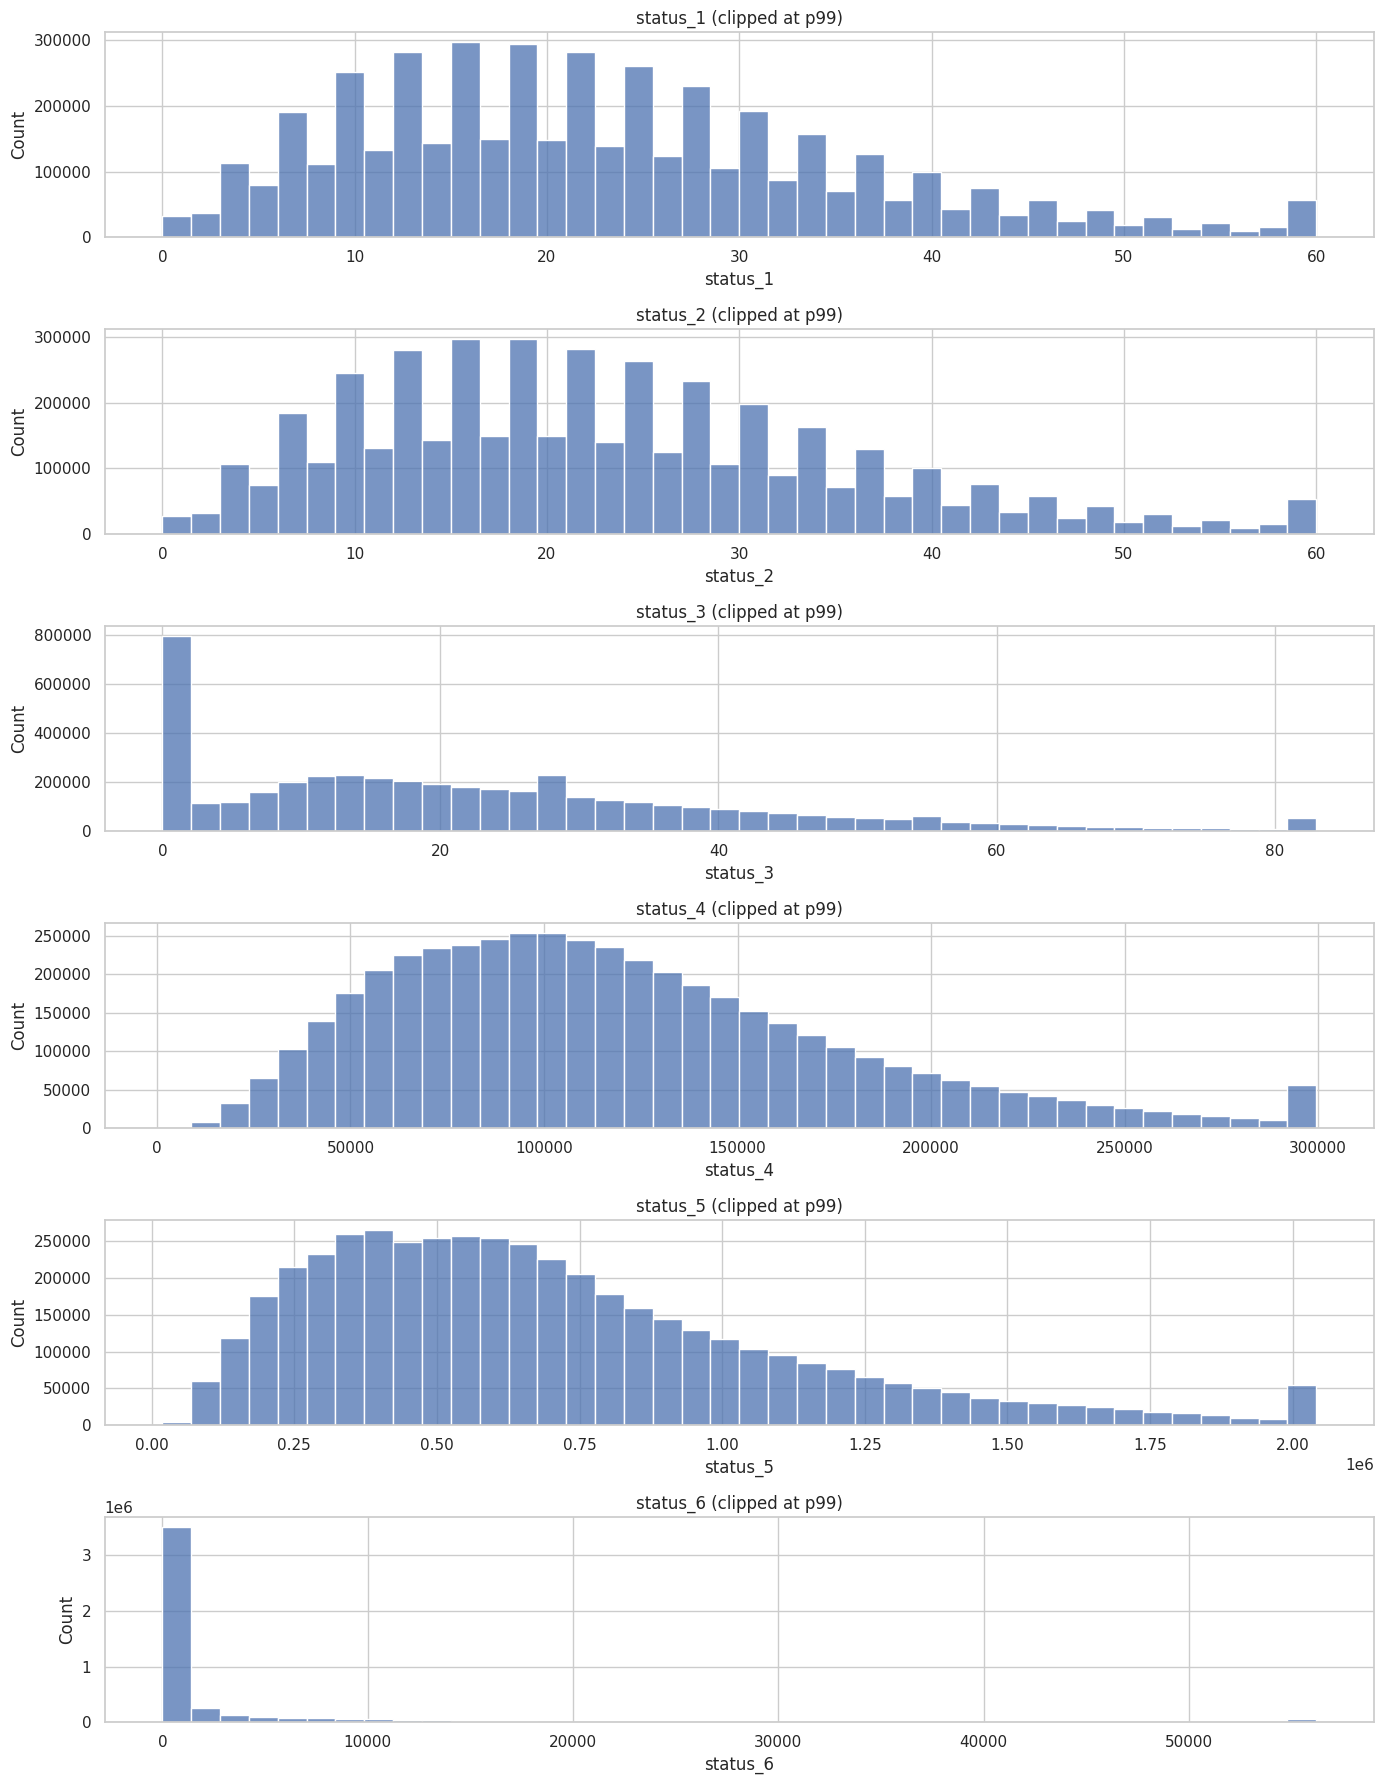

In [21]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 3 * len(status_cols)))
if len(status_cols) == 1:
    axes = [axes]
for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)),
                 bins=40, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")
plt.tight_layout()
plt.show()

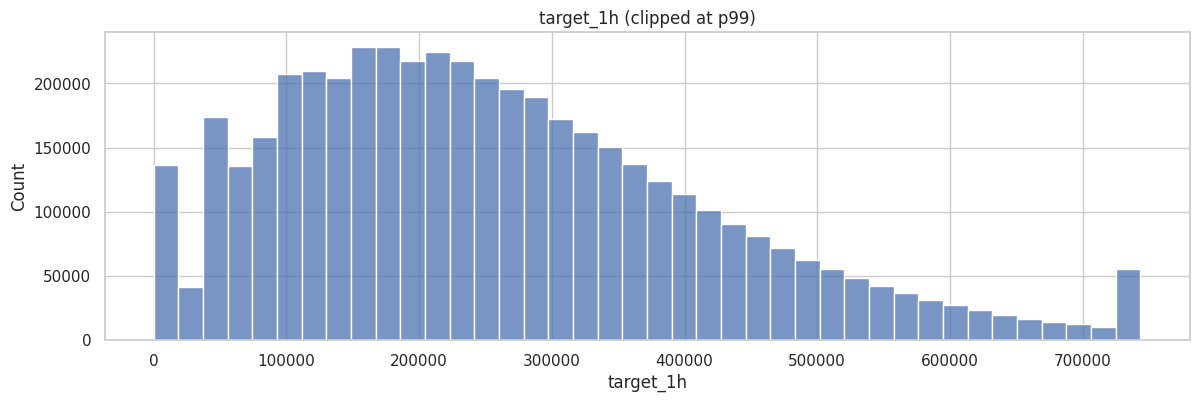

count    4.630000e+06
mean     2.612421e+05
std      1.690826e+05
min      0.000000e+00
25%      1.389900e+05
50%      2.357690e+05
75%      3.551750e+05
max      1.083134e+07
Name: target_1h, dtype: float64


In [22]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)),
             bins=40, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()
print(train_df[TARGET_COL].describe())

In [23]:
import holidays

def get_status_cols(df):
    """Только исходные status_N, без rolling-вариантов status_N_rW."""
    return sorted(c for c in df.columns
                  if c.startswith("status_") and c.count("_") == 1)


def add_time_features(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    t = df["timestamp"]
    df["hour"] = t.dt.hour
    df["dow"]  = t.dt.dayofweek
    df["slot"] = t.dt.hour * 2 + t.dt.minute // 30
    df["date"] = t.dt.date
    return df


def clean_anomalies(df, scols):
    df = df.copy()
    tcols = [TARGET_COL] if TARGET_COL in df.columns else []
    for c in scols + tcols:
        bad = df[c] > ANOMALY_THRESH
        if bad.any():
            print(f"  {c}: убрано {bad.sum()} аномалий")
            df.loc[bad, c] = np.nan
    df = df.sort_values(["route_id", "timestamp"])
    for c in scols + tcols:
        df[c] = df.groupby("route_id")[c].transform(lambda x: x.ffill().bfill())
    return df

def add_target_lags(df):
    df = df.copy()
    df = df.sort_values(["route_id", "timestamp"])

    # 1. Простые лаги
    df["lag_1h"] = df.groupby("route_id")[TARGET_COL].shift(2)
    df["lag_24h"] = df.groupby("route_id")[TARGET_COL].shift(48)

    # 2. Скользящее среднее за 3 часа (Здесь важно закрыть скобку в конце строки)
    df["target_rolling_3h"] = df.groupby("route_id")[TARGET_COL].transform(
        lambda x: x.shift(2).rolling(window=6, min_periods=1).mean()
    )

    # 3. Разница между часом назад и двумя часами назад (Тренд)
    # Считаем отдельно, вне transform
    df['lag_diff'] = df['lag_1h'] - df.groupby("route_id")[TARGET_COL].shift(4)
    df['lag_trend'] = np.sign(df['lag_diff']).fillna(0)

    # Заполняем пустоты нулями для стабильности обучения
    cols_to_fill = ["lag_1h", "lag_24h", "target_rolling_3h", "lag_diff", "lag_trend"]
    df[cols_to_fill] = df[cols_to_fill].fillna(0)

    return df

def add_advanced_features(df):
    df = df.copy()
    # 1. Праздники (Россия)
    ru_holidays = holidays.Russia()
    df['is_holiday'] = df['timestamp'].dt.date.apply(lambda x: 1 if x in ru_holidays else 0)

    # 2. Агрегаты статусов (Потоки на складе)
    # Сумма товаров на текущем складе (этапы 1-3)
    df["status_inbound"] = df["status_1"] + df["status_2"] + df["status_3"]
    # Сумма товаров, уходящих со склада или на пути (этапы 4-6)
    df["status_outbound"] = df["status_4"] + df["status_5"] + df["status_6"]

    # 3. Динамика (изменение входящего потока за 30 мин)
    df['inbound_delta'] = df.groupby('route_id')['status_inbound'].diff().fillna(0)

    return df

def add_rolling_features(df, scols):
    """Rolling mean статусов — улавливает тренд/импульс конвейера."""
    df = df.sort_values(["route_id", "timestamp"])
    for w in ROLL_WINDOWS:
        for c in scols:
            df[f"{c}_r{w}"] = df.groupby("route_id")[c].transform(
                lambda x: x.rolling(w, min_periods=1).mean()
            )
    return df

In [24]:
scols = get_status_cols(train_df)
print("Status cols:", scols)

print("\nОчистка аномалий...")
train_df = clean_anomalies(train_df, scols)

print("Добавление лагов таргета...")
train_df = add_target_lags(train_df)

print("Добавление продвинутых фич (праздники и потоки)...")
train_df = add_advanced_features(train_df)

print("Временны́е фичи...")
train_df = add_time_features(train_df)
test_df  = add_time_features(test_df)

print("Rolling-фичи...")
train_df = add_rolling_features(train_df, scols)

print("Готово. Train shape:", train_df.shape)

Status cols: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']

Очистка аномалий...
  target_1h: убрано 2 аномалий
Добавление лагов таргета...
Добавление продвинутых фич (праздники и потоки)...
Временны́е фичи...
Rolling-фичи...
Готово. Train shape: (4630000, 34)


In [25]:
def build_profiles(train):
    max_ts = train["timestamp"].max()
    mask   = train["timestamp"] >= max_ts - pd.Timedelta(weeks=PROFILE_WEEKS)
    rds = (
        train[mask]
        .groupby(["route_id", "dow", "slot"])[TARGET_COL]
        .mean().reset_index()
        .rename(columns={TARGET_COL: "prof"})
    )
    rs = (
        train
        .groupby(["route_id", "slot"])[TARGET_COL]
        .mean().reset_index()
        .rename(columns={TARGET_COL: "prof_rs"})
    )
    return rds, rs

def add_target_encoding(train, df_to_fix):
    # Считаем среднее по связке Маршрут + Час
    te = train.groupby(['route_id', 'hour'])[TARGET_COL].mean().reset_index()
    te.columns = ['route_id', 'hour', 'route_hour_mean']

    # Приклеиваем к данным
    df_to_fix = df_to_fix.merge(te, on=['route_id', 'hour'], how='left')
    df_to_fix['route_hour_mean'] = df_to_fix['route_hour_mean'].fillna(df_to_fix[TARGET_COL].mean())
    return df_to_fix

def attach_profile(df, rds, rs):
    df = df.merge(rds, on=["route_id", "dow", "slot"], how="left")
    df = df.merge(rs,  on=["route_id", "slot"],        how="left")
    df["prof"] = df["prof"].fillna(df["prof_rs"]).fillna(0)
    df.drop(columns=["prof_rs"], errors="ignore", inplace=True)
    return df


rds, rs = build_profiles(train_df)
print(f"Профиль: {len(rds):,} записей")
display(rds.head())

Профиль: 336,000 записей


,route_id,dow,slot,prof
0,0,0,0,170045.125
1,0,0,1,205007.000
2,0,0,2,147431.000
3,0,0,3,164218.250
4,0,0,4,183956.875


In [26]:
def build_morning_totals(train):
    """Полная утренняя сумма target по (route_id, date) для слотов 0–21."""
    morn = train[train["slot"].isin(MORNING_SLOTS)]
    return (
        morn.groupby(["route_id", "date"])[TARGET_COL]
            .sum().reset_index()
            .rename(columns={TARGET_COL: "morning_total"})
    )


def build_morning_avg(train, morning_totals):
    """Среднее morning_total по (route_id, dow) — для нормировки."""
    mt = morning_totals.copy()
    mt["dow"] = pd.to_datetime(mt["date"]).dt.dayofweek
    return (
        mt.groupby(["route_id", "dow"])["morning_total"]
          .mean().reset_index()
          .rename(columns={"morning_total": "morning_avg"})
    )


def attach_morning_ratio(df, morning_totals, morning_avg):
    df = df.merge(morning_totals, on=["route_id", "date"], how="left")
    df = df.merge(morning_avg,    on=["route_id", "dow"],  how="left")
    df["morning_ratio"] = (
        df["morning_total"].fillna(df["morning_avg"])
        / df["morning_avg"].replace(0, np.nan)
    ).fillna(1.0)
    df.drop(columns=["morning_total", "morning_avg"], errors="ignore", inplace=True)
    return df


mt = build_morning_totals(train_df)
ma = build_morning_avg(train_df, mt)
print(f"morning_totals: {len(mt):,} записей")

# Быстрая проверка: корреляция morning_total с afternoon target на субботах
sat = train_df[train_df["dow"] == 5].copy()
sat_aft = sat[sat["slot"].isin(range(22, 30))].merge(mt, on=["route_id", "date"])
corr = sat_aft["morning_total"].corr(sat_aft[TARGET_COL])
print(f"Корреляция morning_total ↔ {TARGET_COL} (суббота послеполудни): {corr:.3f}")

morning_totals: 97,000 записей
Корреляция morning_total ↔ target_1h (суббота послеполудни): 0.669


In [27]:
def build_ml_dataset(train, rds, rs, scols): # Убрали лишние аргументы totals/avg
    max_ts = train["timestamp"].max()
    cutoff = max_ts - pd.Timedelta(weeks=ML_WEEKS)
    rec    = train[train["timestamp"] >= cutoff].copy()
    rec    = attach_profile(rec, rds, rs)
    # УБРАЛИ: attach_morning_ratio

    rcols    = [c for c in rec.columns if any(f"_r{w}" in c for w in ROLL_WINDOWS)]
    new_features = [
        "lag_1h", "lag_24h", "target_rolling_3h",
        "is_holiday", "status_inbound", "status_outbound", "inbound_delta"
    ]
    src_cols = scols + rcols + new_features

    parts = []
    for route_id, grp in rec.groupby("route_id"):
        grp = grp.sort_values("timestamp").reset_index(drop=True)
        n   = len(grp)
        if n <= MAX_HORIZON:
            continue

        sa  = grp[src_cols].to_numpy(dtype=float)
        hr  = grp["hour"].to_numpy()
        dw  = grp["dow"].to_numpy()
        sl  = grp["slot"].to_numpy()
        pr  = grp["prof"].to_numpy()
        tgt = grp[TARGET_COL].to_numpy()

        for h in range(1, MAX_HORIZON + 1):
            m = n - h
            chunk = pd.DataFrame(sa[:m], columns=src_cols)
            chunk["hour"]          = hr[h:h + m]
            chunk["dow"]           = dw[h:h + m]
            chunk["slot"]          = sl[h:h + m]
            chunk["prof"]          = pr[h:h + m]
            chunk["h"]             = h
            chunk["route_id"]      = route_id
            chunk["y"]             = tgt[h:h + m]
            parts.append(chunk)

    df = pd.concat(parts, ignore_index=True)
    if len(df) > MAX_SAMPLES:
        df = df.sample(MAX_SAMPLES, random_state=42)
    return df

# Вызов теперь проще:
print("Строим ML-датасет (без утренних коэффициентов)...")
samples = build_ml_dataset(train_df, rds, rs, scols)

Строим ML-датасет (без утренних коэффициентов)...


In [28]:
feature_cols = [c for c in samples.columns if c != "y"]
X = samples[feature_cols]
y = samples["y"].clip(lower=0)

cat_features = [f for f in ["route_id", "dow", "slot", "h", "hour"] if f in feature_cols]

print("Feature cols:", feature_cols)
print("Cat features:", cat_features)
print("Train rows:",   len(X))

print("Обучаем LightGBM...")
lgb_model = lgb.LGBMRegressor(**LGBM_PARAMS)
lgb_model.fit(X, y, categorical_feature=cat_features)

print("\nОбучаем CatBoost (это может занять время)...")
# Указываем CatBoost, какие признаки — категории
cat_features_idx = [X.columns.get_loc(c) for c in cat_features]
cb_model = CatBoostRegressor(**CB_PARAMS)
cb_model.fit(X, y, cat_features=cat_features_idx)

print("\nОбучение обеих моделей завершено!")

Feature cols: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_1_r4', 'status_2_r4', 'status_3_r4', 'status_4_r4', 'status_5_r4', 'status_6_r4', 'status_1_r12', 'status_2_r12', 'status_3_r12', 'status_4_r12', 'status_5_r12', 'status_6_r12', 'lag_1h', 'lag_24h', 'target_rolling_3h', 'is_holiday', 'status_inbound', 'status_outbound', 'inbound_delta', 'hour', 'dow', 'slot', 'prof', 'h', 'route_id']
Cat features: ['route_id', 'dow', 'slot', 'h', 'hour']
Train rows: 3000000
Обучаем LightGBM...

Обучаем CatBoost (это может занять время)...
0:	learn: 131655.2920093	total: 7.42s	remaining: 2h 3m 27s
100:	learn: 89774.1088941	total: 9m 5s	remaining: 1h 20m 57s
200:	learn: 89076.8130306	total: 18m 12s	remaining: 1h 12m 21s
300:	learn: 88371.0898603	total: 27m 22s	remaining: 1h 3m 34s
400:	learn: 87926.3981432	total: 36m 51s	remaining: 55m 3s
500:	learn: 87602.2090654	total: 46m 24s	remaining: 46m 13s
600:	learn: 87370.7835365	total: 55m 58s	remaining: 37m 9s
700:	

/tmp/ipykernel_3569/1926863310.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_lgb, x="gain", y="feature", palette="viridis")


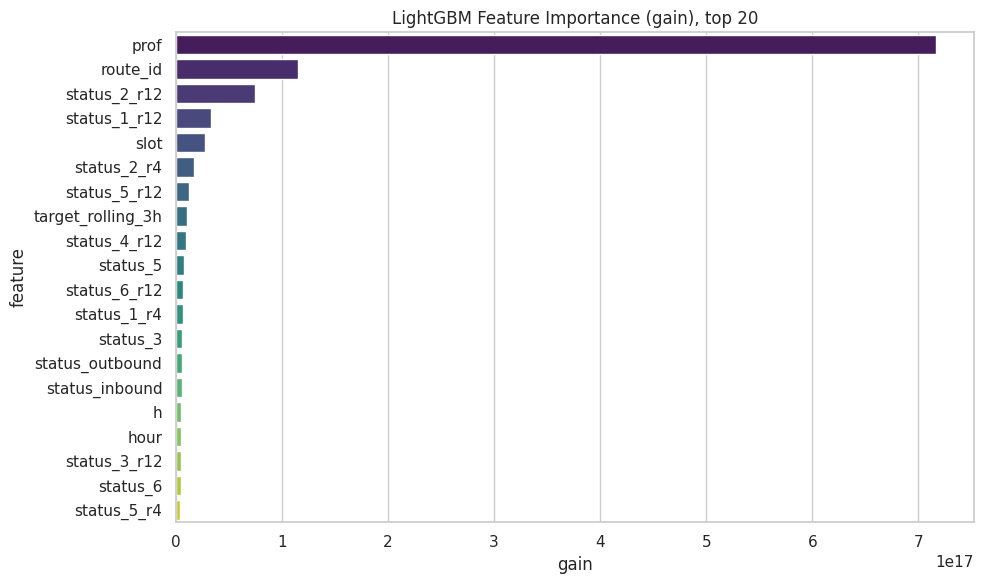

/tmp/ipykernel_3569/1926863310.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_cb, x="gain", y="feature", palette="magma")


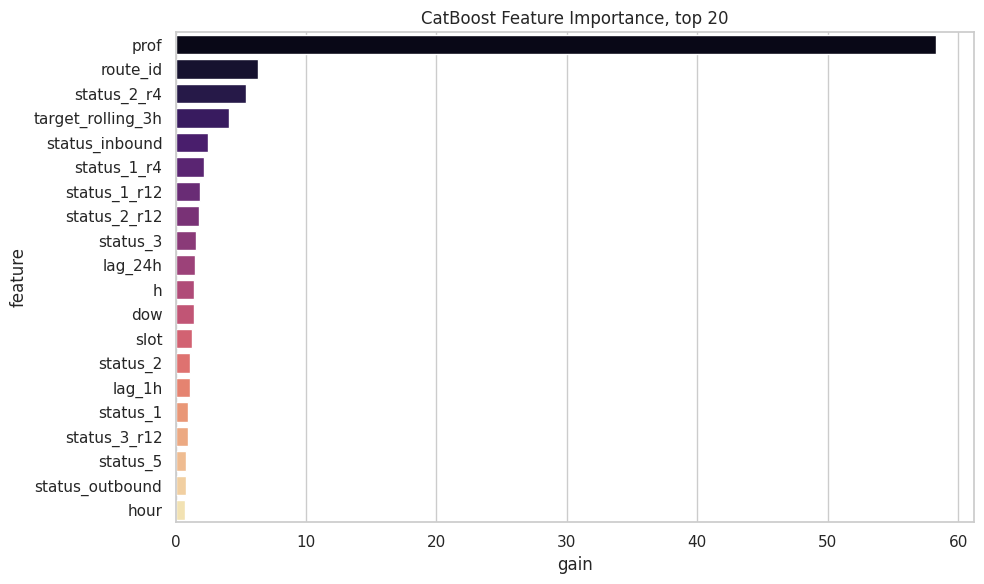

In [29]:
# 1. Feature importance для LightGBM
imp_lgb = pd.DataFrame({
    "feature": feature_cols,
    "gain":    lgb_model.booster_.feature_importance(importance_type="gain")
}).sort_values("gain", ascending=False).head(20)

# 2. Feature importance для CatBoost (у него немного другой метод)
imp_cb = pd.DataFrame({
    "feature": feature_cols,
    "gain":    cb_model.get_feature_importance()
}).sort_values("gain", ascending=False).head(20)

# Визуализация LightGBM
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_lgb, x="gain", y="feature", palette="viridis")
plt.title("LightGBM Feature Importance (gain), top 20")
plt.tight_layout()
plt.show()

# Визуализация CatBoost
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_cb, x="gain", y="feature", palette="magma")
plt.title("CatBoost Feature Importance, top 20")
plt.tight_layout()
plt.show()

In [38]:
def predict_for_df(test, train, rds, rs, model, feat_cols, scols):
    last_ts = train["timestamp"].max()
    rcols = [c for c in train.columns if any(f"_r{w}" in c for w in ROLL_WINDOWS)]

    # 1. Признаки, которые берем как "последнее состояние"
    new_features_from_last = [
        "lag_1h", "lag_24h", "target_rolling_3h",
        "is_holiday", "status_inbound", "status_outbound", "inbound_delta",
        "lag_diff", "lag_trend"
    ]

    last_rows = (
        train.sort_values(["route_id", "timestamp"])
             .groupby("route_id")[scols + rcols + [f for f in new_features_from_last if f in train.columns]]
             .last().reset_index()
    )

    t = test.copy()

    # 2. Добавляем время (строго как int)
    t["hour"] = t["timestamp"].dt.hour.astype(int)
    t["dow"]  = t["timestamp"].dt.dayofweek.astype(int)
    t["slot"] = (t["timestamp"].dt.hour * 2 + t["timestamp"].dt.minute // 30).astype(int)

    t = t.merge(last_rows, on="route_id", how="left")
    t = attach_profile(t, rds, rs)

    # 3. Target Encoding (если его нет в train, считаем на лету)
    if 'route_hour_mean' in train.columns:
        te_map = train.groupby(['route_id', 'hour'])['route_hour_mean'].first().reset_index()
    else:
        te_map = train.groupby(['route_id', 'hour'])[TARGET_COL].mean().reset_index()
        te_map.columns = ['route_id', 'hour', 'route_hour_mean']

    t = t.merge(te_map, on=['route_id', 'hour'], how='left')
    t['route_hour_mean'] = t['route_hour_mean'].fillna(train[TARGET_COL].mean())

    # 4. Вычисляем горизонт (строго int)
    t["h"] = ((t["timestamp"] - last_ts).dt.total_seconds() / 1800).round().astype(int)

    # 5. ИСПРАВЛЕНИЕ ОШИБКИ: Приведение типов для CatBoost
    cat_cols = ["route_id", "dow", "slot", "h", "hour"]

    for c in feat_cols:
        if c not in t.columns:
            t[c] = 0 # Используем целое число 0 по умолчанию

    # Принудительно превращаем категории в int
    for c in cat_cols:
        if c in t.columns:
            t[c] = t[c].fillna(0).astype(int)

    return model.predict(t[feat_cols]).clip(min=0)

In [39]:
# 1. Получаем прогнозы
y_lgb = predict_for_df(test_df, train_df, rds, rs, lgb_model, feature_cols, scols)
y_cb = predict_for_df(test_df, train_df, rds, rs, cb_model, feature_cols, scols)

# 2. Смешиваем: 70% на объем (LGBM), 30% на точность (CB)
y_ml = 0.7 * y_lgb + 0.3 * y_cb

# 3. ФИНАЛЬНАЯ КОРРЕКЦИЯ (Убираем Bias 4.8%)
y_ml = y_ml * 1.05

# 4. Добавляем профиль (всего 5% для гибкости)
NEW_PROFILE_BLEND = 0.05
test_df2 = attach_profile(test_df.copy(), rds, rs)
y_prof = test_df2["prof"].clip(lower=0).values

test_df["y_pred"] = ((1 - NEW_PROFILE_BLEND) * y_ml + NEW_PROFILE_BLEND * y_prof).clip(min=0)

# Ограничитель сверху
test_df["y_pred"] = test_df["y_pred"].clip(upper=train_df[TARGET_COL].max())

print(f"Сабмит готов! Профиль: {NEW_PROFILE_BLEND}, Коррекция: 1.05")

Сабмит готов! Профиль: 0.05, Коррекция: 1.05


In [41]:
# N_FOLDS      = 2
# TEST_DOW     = 5           # суббота
# TEST_SLOTS   = list(range(22, 30))  # 11:00–14:30
# MORNING_SLOT = 22

# dates = sorted(train_df[train_df["dow"] == TEST_DOW]["date"].unique())
# print(f"Доступно {len(dates)} суббот для валидации")

# scores = []
# for i in range(N_FOLDS):
#     val_date = dates[-(i + 2)]
#     val_ts   = pd.Timestamp(val_date)

#     val = train_df[(train_df["date"] == val_date) & train_df["slot"].isin(TEST_SLOTS)].copy()
#     tr_fold = train_df[
#         (train_df["timestamp"] < val_ts) |
#         ((train_df["date"] == val_date) & (train_df["slot"] < MORNING_SLOT))
#     ].copy()

#     sc_fold      = get_status_cols(tr_fold)
#     rds_, rs_    = build_profiles(tr_fold)
#     mt_          = build_morning_totals(tr_fold)
#     ma_          = build_morning_avg(tr_fold, mt_)
#     samp_        = build_ml_dataset(tr_fold, rds_, rs_, sc_fold, mt_, ma_)

#     fc_ = [c for c in samp_.columns if c != "y"]
#     cat_ = [f for f in ["route_id", "dow", "slot", "h", "hour"] if f in fc_]
#     # 1. Обучаем LightGBM для этого фолда
#     mdl_lgb = lgb.LGBMRegressor(**LGBM_PARAMS)
#     mdl_lgb.fit(samp_[fc_], samp_["y"].clip(lower=0), categorical_feature=cat_)

#     # 2. Обучаем CatBoost для этого фолда
#     # Сначала найдем индексы категориальных признаков
#     cat_idx_ = [samp_[fc_].columns.get_loc(c) for c in cat_]
#     mdl_cb = CatBoostRegressor(**CB_PARAMS)
#     mdl_cb.fit(samp_[fc_], samp_["y"].clip(lower=0), cat_features=cat_idx_)

#     # 3. Делаем предсказания обеими моделями
#     y_lgb_val = predict_for_df(val, tr_fold, rds_, rs_, mdl_lgb, fc_, sc_fold, mt_, ma_)
#     y_cb_val  = predict_for_df(val, tr_fold, rds_, rs_, mdl_cb, fc_, sc_fold, mt_, ma_)

#     # 4. Смешиваем их 50/50 (как и в финальном прогнозе)
#     y_ml = 0.5 * y_lgb_val + 0.5 * y_cb_val
#     val    = attach_profile(val.copy(), rds_, rs_)
#     y_prof = val["prof"].clip(lower=0).values
#     y_pred = (1 - PROFILE_BLEND) * y_ml + PROFILE_BLEND * y_prof

#     m = calc_metric(val[TARGET_COL].values, y_pred)
#     scores.append(m["total"])
#     print(f"Fold {i+1} ({val_date}): WAPE={m['wape']:.4f}  RBias={m['rbias']:.4f}  Total={m['total']:.4f}")

# print(f"\nСреднее: {np.mean(scores):.4f}")

In [42]:
# 1. Получаем прогноз от LightGBM (убрали mt, ma в конце)
print("Предсказание LightGBM...")
y_lgb = predict_for_df(test_df, train_df, rds, rs, lgb_model, feature_cols, scols)

# 2. Получаем прогноз от CatBoost (убрали mt, ma в конце)
print("Предсказание CatBoost...")
y_cb = predict_for_df(test_df, train_df, rds, rs, cb_model, feature_cols, scols)

# Баланс 70% на объем (LGBM) и 30% на точность (CB)
y_ml = 0.7 * y_lgb + 0.3 * y_cb

# Оставляем множитель 1.0 (без ручных правок)
y_ml = y_ml * 1.0

# 4. Добавляем исторический профиль
test_df2 = attach_profile(test_df.copy(), rds, rs)
y_prof = test_df2["prof"].clip(lower=0).values

# Итоговое предсказание
test_df["y_pred"] = ((1 - PROFILE_BLEND) * y_ml + PROFILE_BLEND * y_prof).clip(min=0)

# Ограничитель сверху
max_train_target = train_df[TARGET_COL].max()
test_df["y_pred"] = test_df["y_pred"].clip(upper=max_train_target)

print(f"Прогноз готов с профилем {PROFILE_BLEND} и БЕЗ коэффициентов.")

Предсказание LightGBM...
Предсказание CatBoost...
Прогноз готов с профилем 0.05 и БЕЗ коэффициентов.


In [43]:
submission = test_df[["id", "y_pred"]].copy()

# Проверки
assert list(submission.columns) == ["id", "y_pred"], "Неверные колонки"
assert submission["id"].duplicated().sum() == 0, "Дубликаты id"
assert submission["y_pred"].isna().sum() == 0, "Есть NaN в y_pred"
assert (submission["y_pred"] < 0).sum() == 0, "Есть отрицательные значения"

submission_path = f"submission_{TRACK}.csv"
submission.to_csv(submission_path, index=False)

print(f"Сохранено: {submission_path} ({len(submission)} строк)")
display(submission.head(10))

Сохранено: submission_solo.csv (8000 строк)


,id,y_pred
0,3920,175056.399244
1,3921,186734.053515
2,3922,170380.663357
3,3923,188027.238586
4,3924,196851.874007
5,3925,179180.496852
6,3926,149309.819592
7,3927,128761.429135
8,5072,88804.367696
9,5073,49724.431484


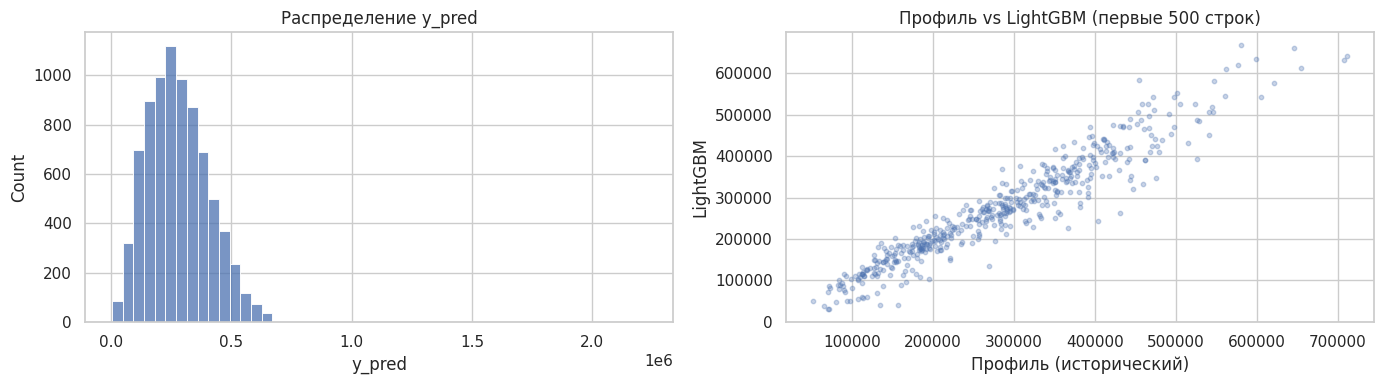

In [44]:
# Визуализация распределения предсказаний
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(submission["y_pred"], bins=50, ax=axes[0])
axes[0].set_title("Распределение y_pred")

# Сравнение с профилем
test_with_prof = test_df[["id", "y_pred"]].merge(
    test_df2[["id", "prof"]] if "id" in test_df2.columns else test_df[["route_id","slot","dow"]].assign(id=test_df["id"]).merge(rds, on=["route_id","dow","slot"]).rename(columns={"prof":"prof"}),
    on="id", how="left"
)
axes[1].scatter(test_df2["prof"].values[:500], y_ml[:500], alpha=0.3, s=10)
axes[1].set_xlabel("Профиль (исторический)")
axes[1].set_ylabel("LightGBM")
axes[1].set_title("Профиль vs LightGBM (первые 500 строк)")

plt.tight_layout()
plt.show()